In [1]:
import os
import sys
import pandas as pd

# Ensure project root is in sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.optimization import build_return_cov, optimize_max_sharpe, optimize_min_vol


# Load price histories
df_tsla = pd.read_csv("../data/processed/tsla_cleaned.csv", parse_dates=["Date"], index_col="Date")
df_bnd  = pd.read_csv("../data/processed/bnd_cleaned.csv", parse_dates=["Date"], index_col="Date")
df_spy  = pd.read_csv("../data/processed/spy_cleaned.csv", parse_dates=["Date"], index_col="Date")

# Ensure numeric dtype for Close columns
for df in [df_tsla, df_bnd, df_spy]:
    df["Close"] = pd.to_numeric(df["Close"], errors="coerce")

# Drop any rows with NaNs after conversion
df_tsla.dropna(subset=["Close"], inplace=True)
df_bnd.dropna(subset=["Close"], inplace=True)
df_spy.dropna(subset=["Close"], inplace=True)

# Build price dataframe
price_df = pd.concat([df_tsla["Close"], df_bnd["Close"], df_spy["Close"]], axis=1)
price_df.columns = ["TSLA","BND","SPY"]

# Forecast implied expected return (annualized)
future_series = df_tsla["Close"]
tsla_expected_return = future_series.pct_change().mean() * 252

# Now safe to call build_return_cov
mu, cov = build_return_cov(price_df, tsla_expected_return)


In [2]:
weights_sharpe, perf_sharpe = optimize_max_sharpe(mu, cov)
weights_minvol, perf_minvol = optimize_min_vol(mu, cov)

print("Max Sharpe weights:", weights_sharpe)
print("Max Sharpe performance:", perf_sharpe)
print("Min Vol weights:", weights_minvol)
print("Min Vol performance:", perf_minvol)


Expected annual return: 10.6%
Annual volatility: 11.0%
Sharpe Ratio: 0.96
Expected annual return: 2.6%
Annual volatility: 5.3%
Sharpe Ratio: 0.49
Max Sharpe weights: OrderedDict({'TSLA': 0.11746, 'BND': 0.59679, 'SPY': 0.28575})
Max Sharpe performance: (np.float64(0.10592033604383973), np.float64(0.11017546962864348), np.float64(0.9613785754746853))
Min Vol weights: OrderedDict({'TSLA': 0.0, 'BND': 0.94272, 'SPY': 0.05728})
Min Vol performance: (np.float64(0.025835211649157832), np.float64(0.05256541639521539), np.float64(0.49148686381393153))


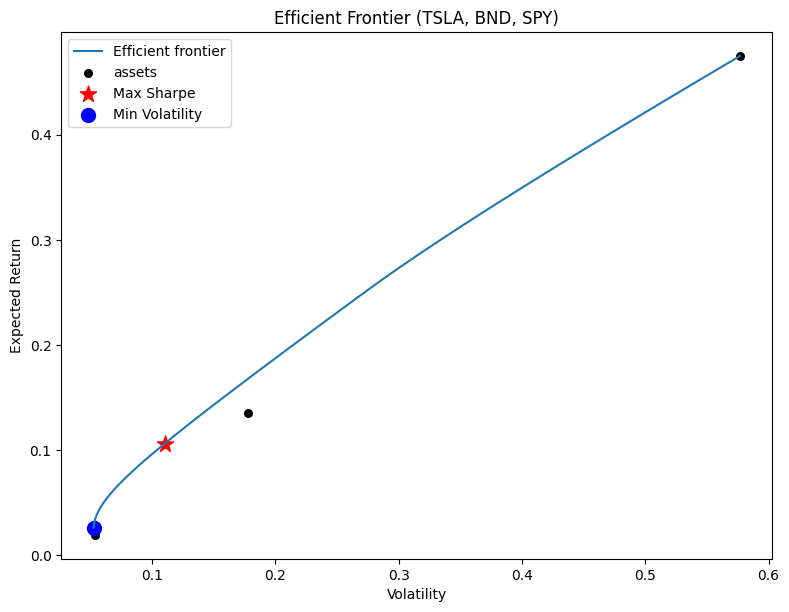

In [3]:
from pypfopt.efficient_frontier import EfficientFrontier

from pypfopt import plotting
import matplotlib.pyplot as plt

ef = EfficientFrontier(mu, cov)
fig, ax = plt.subplots(figsize=(8,6))
plotting.plot_efficient_frontier(ef, ax=ax)

ret_sharpe, vol_sharpe, _ = perf_sharpe
ret_min, vol_min, _ = perf_minvol

ax.scatter(vol_sharpe, ret_sharpe, marker="*", color="r", s=150, label="Max Sharpe")
ax.scatter(vol_min, ret_min, marker="o", color="b", s=100, label="Min Volatility")
ax.set_title("Efficient Frontier (TSLA, BND, SPY)")
ax.set_xlabel("Volatility")
ax.set_ylabel("Expected Return")
ax.legend()
plt.show()
